In [1]:
# === FULL SIAMESE NETWORK WITH RESNET BACKBONE, CONTRASTIVE LOSS, TRAINING + TSNE ===

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet50
from PIL import Image
import os
import random
import numpy as np
from sklearn.manifold import TSNE
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
class SiameseNetwork(nn.Module):
    def __init__(self):
        super(SiameseNetwork, self).__init__()
        base_model = resnet50(pretrained=True)
        base_model.fc = nn.Identity()
        self.cnn = base_model

    def forward_once(self, x):
        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        x = self.cnn(x)
        x = F.normalize(x, p=2, dim=1)
        return x

    def forward(self, x1, x2):
        out1 = self.forward_once(x1)
        out2 = self.forward_once(x2)
        return out1, out2


In [3]:
class SiameseDataset(Dataset):
    def __init__(self, image_folder_dataset, transform=None):
        self.image_folder_dataset = image_folder_dataset
        self.transform = transform
        self.classes = list(image_folder_dataset.class_to_idx.keys())
        self.class_to_images = {cls: [] for cls in self.classes}

        for img_path, label in image_folder_dataset.samples:
            cls_name = self.classes[label]
            self.class_to_images[cls_name].append(img_path)

    def __getitem__(self, index):
        cls1 = random.choice(self.classes)
        is_same = random.randint(0, 1)

        img1_path = random.choice(self.class_to_images[cls1])
        img1 = Image.open(img1_path).convert("L")

        if is_same:
            img2_path = random.choice(self.class_to_images[cls1])
        else:
            cls2 = random.choice([c for c in self.classes if c != cls1])
            img2_path = random.choice(self.class_to_images[cls2])

        img2 = Image.open(img2_path).convert("L")

        if self.transform:
            img1 = self.transform(img1)
            img2 = self.transform(img2)

        label = torch.tensor(float(is_same), dtype=torch.float32)
        return img1, img2, label

    def __len__(self):
        return sum(len(paths) for paths in self.class_to_images.values())


In [4]:
class ContrastiveLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(ContrastiveLoss, self).__init__()
        self.margin = margin

    def forward(self, out1, out2, label):
        dist = F.pairwise_distance(out1, out2)
        loss = (label) * torch.pow(dist, 2) + \
               (1 - label) * torch.pow(torch.clamp(self.margin - dist, min=0.0), 2)
        return loss.mean()


In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_path = "/kaggle/input/flowers-recognition/flowers"  # change if needed
image_dataset = ImageFolder(dataset_path)
siamese_dataset = SiameseDataset(image_dataset, transform=transform)
train_loader = DataLoader(siamese_dataset, shuffle=True, batch_size=32)


In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SiameseNetwork().to(device)
criterion = ContrastiveLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for img1, img2, label in train_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        out1, out2 = model(img1, img2)
        loss = criterion(out1, out2, label)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {total_loss/len(train_loader):.4f}")


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s] 


Epoch [1/10], Loss: 0.1710
Epoch [2/10], Loss: 0.0961
Epoch [3/10], Loss: 0.0679
Epoch [4/10], Loss: 0.0525
Epoch [5/10], Loss: 0.0386
Epoch [6/10], Loss: 0.0315
Epoch [7/10], Loss: 0.0302
Epoch [8/10], Loss: 0.0219
Epoch [9/10], Loss: 0.0153
Epoch [10/10], Loss: 0.0166


In [17]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

def plot_tsne_from_embeddings(features, labels, class_names):
    """
    Plot t-SNE graph with distinct colors for each class.
    Args:
        features (ndarray): Embeddings from Siamese model
        labels (list or ndarray): Corresponding class indices
        class_names (list): List of class name strings
    """
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    tsne_result = tsne.fit_transform(features)

    labels_np = np.array(labels)

    plt.figure(figsize=(10, 8))
    for class_idx, class_name in enumerate(class_names):
        idxs = labels_np == class_idx
        plt.scatter(tsne_result[idxs, 0], tsne_result[idxs, 1],
                    label=class_name, alpha=0.7, s=20)

    plt.legend()
    plt.title('t-SNE Visualization of Siamese Network Embeddings')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [43]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np

def plot_tsne_from_embeddings(features, labels, class_names):
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    tsne_result = tsne.fit_transform(features)

    labels_np = np.array(labels)

    plt.figure(figsize=(10, 8))
    for class_idx, class_name in enumerate(class_names):
        idxs = labels_np == class_idx
        plt.scatter(tsne_result[idxs, 0], tsne_result[idxs, 1],
                    label=class_name, alpha=0.7, s=20)

    plt.legend()
    plt.title('t-SNE Visualization of Siamese Network Embeddings')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


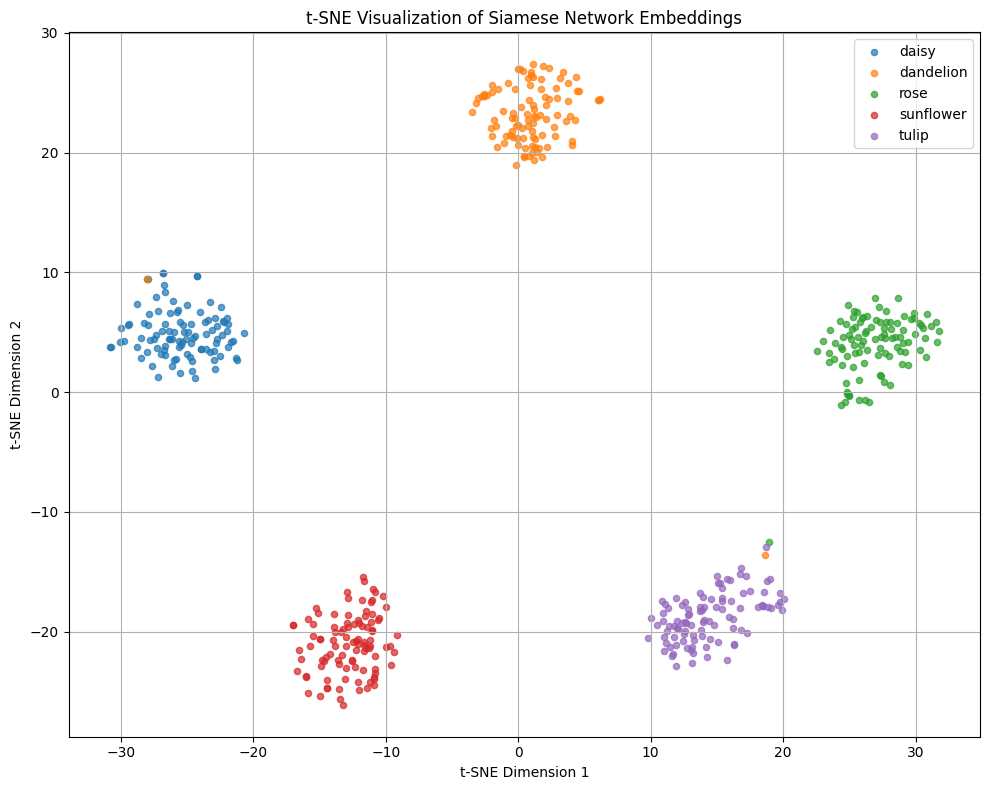

In [36]:
def get_features(model, dataset, transform, n_samples_per_class=100):
    model.eval()
    features = []
    labels = []

    with torch.no_grad():
        for class_idx, class_name in enumerate(dataset.classes):
            class_paths = [s for s in dataset.samples if s[1] == class_idx][:n_samples_per_class]
            for path, label in class_paths:
                img = Image.open(path).convert("L")
                img = transform(img).unsqueeze(0).to(device)
                embed = model.forward_once(img).cpu().squeeze().numpy()
                features.append(embed)
                labels.append(label)

    return np.array(features), np.array(labels)


features, labels = get_features(model, image_dataset, transform)
class_names = image_dataset.classes

plot_tsne_from_embeddings(features, labels, class_names)


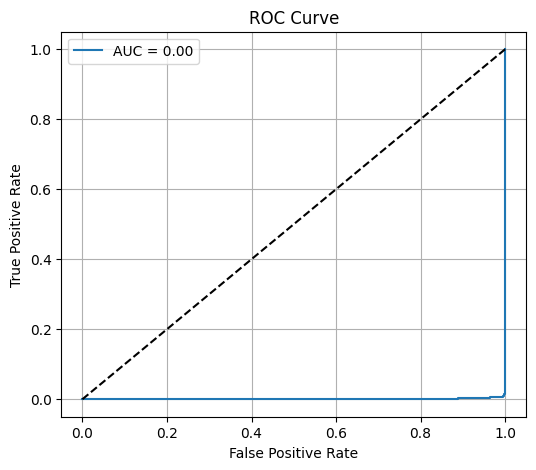

In [44]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import torch.nn.functional as F

def plot_roc_curve(model, loader):
    model.eval()
    y_true = []
    y_scores = []

    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            dist = F.pairwise_distance(out1, out2).cpu().numpy()
            y_scores.extend(dist)
            y_true.extend(label.numpy())

    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

# Usage:
plot_roc_curve(model, train_loader)


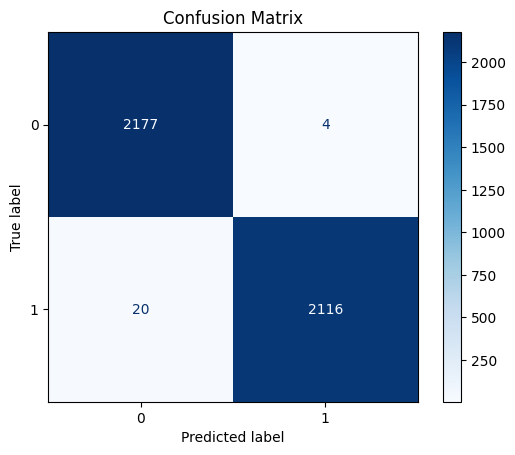

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, loader, threshold=0.5):
    model.eval()
    y_true = []
    y_scores = []

    with torch.no_grad():
        for img1, img2, label in loader:
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)
            dist = F.pairwise_distance(out1, out2).cpu().numpy()
            y_scores.extend(dist)
            y_true.extend(label.numpy())

    # Predict: same (1) if distance < threshold, else different (0)
    y_pred = [1 if score < threshold else 0 for score in y_scores]

    # Generate and plot confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title("Confusion Matrix")
    plt.grid(False)
    plt.show()

# Usage
plot_confusion_matrix(model, train_loader)


In [45]:
# Save the trained model
torch.save(model.state_dict(), "siamese_resnet_model.pth")
print("Model saved as siamese_resnet_model.pth")


Model saved as siamese_resnet_model.pth


In [46]:
def generate_embeddings(model, loader, max_batches=100):
    model.eval()
    embeddings = []
    labels = []

    with torch.no_grad():
        for i, (img1, img2, label) in enumerate(loader):
            img1, img2 = img1.to(device), img2.to(device)
            out1, out2 = model(img1, img2)

            pair_features = torch.abs(out1 - out2)  # Distance-based feature
            embeddings.append(pair_features.cpu())
            labels.append(label.cpu())

            if i >= max_batches:
                break

    X = torch.cat(embeddings).numpy()
    y = torch.cat(labels).numpy()
    return X, y

X_train, y_train = generate_embeddings(model, train_loader)


In [50]:
class EmbeddingClassifier(nn.Module):
    def __init__(self, input_dim):
        super(EmbeddingClassifier, self).__init__()
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.classifier(x)

# Initialize model
input_dim = X_train.shape[1]
clf_model = EmbeddingClassifier(input_dim).to(device)
clf_criterion = nn.BCELoss()
clf_optimizer = torch.optim.Adam(clf_model.parameters(), lr=1e-4)

# Convert data to tensors
X_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)


In [53]:
torch.save(clf_model.state_dict(), "embedding_classifier.pth")
print("Classifier model saved as embedding_classifier.pth")


Classifier model saved as embedding_classifier.pth


In [62]:
num_epochs = 10
for epoch in range(num_epochs):
    clf_model.train()
    outputs = clf_model(X_tensor)
    loss = clf_criterion(outputs, y_tensor)

    clf_optimizer.zero_grad()
    loss.backward()
    clf_optimizer.step()

    preds = (outputs > 0.5).cpu().detach().numpy()
    true = y_tensor.cpu().detach().numpy()

    acc = (preds == true).mean()
    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Accuracy: {acc:.4f}")


Epoch 1, Loss: 0.5472, Accuracy: 0.4938
Epoch 2, Loss: 0.5437, Accuracy: 0.4938
Epoch 3, Loss: 0.5407, Accuracy: 0.4938
Epoch 4, Loss: 0.5363, Accuracy: 0.4938
Epoch 5, Loss: 0.5336, Accuracy: 0.4938
Epoch 6, Loss: 0.5308, Accuracy: 0.4938
Epoch 7, Loss: 0.5273, Accuracy: 0.4938
Epoch 8, Loss: 0.5239, Accuracy: 0.4938
Epoch 9, Loss: 0.5209, Accuracy: 0.4938
Epoch 10, Loss: 0.5173, Accuracy: 0.4938


In [63]:
from sklearn.metrics import classification_report

clf_model.eval()
with torch.no_grad():
    outputs = clf_model(X_tensor)
    preds = (outputs > 0.5).cpu().numpy()
    true = y_tensor.cpu().numpy()

print("\nFinal Classification Report:\n")
print(classification_report(true, preds, target_names=["Different Class", "Same Class"]))



Final Classification Report:

                 precision    recall  f1-score   support

Different Class       0.49      1.00      0.66      1596
     Same Class       0.00      0.00      0.00      1636

       accuracy                           0.49      3232
      macro avg       0.25      0.50      0.33      3232
   weighted avg       0.24      0.49      0.33      3232



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
